### 1. Copying variables and data structures
---

Assigning one variable to another using the equal sign (=) in Python creates a reference to the same object, not a copy. This means that if there is a change the value of one variable, the other variable will also reflect that change because both variables point to the same object in memory. This is known as variable aliasing.

In [1]:
%%python3 -m venv .venv
%%source .venv/bin/activate   # Linux / Mac
#.venv\Scripts\activate      # Windows
%pip install seaborn matplotlib numpy scipy%

In [2]:

original_list = [1, 2, 3]
copied_list = original_list  # Assigning by =
copied_list[0] = 999


print("Original List:", original_list)
print("Copied List:", copied_list)

Original List: [999, 2, 3]
Copied List: [999, 2, 3]


Shallow Copy

A shallow copy creates a new object, but it does not create copies of objects contained within the original variable. Instead, it references the same objects.

In [3]:
# Original list
original_list = [1, 2, [3, 4]]

# Create a shallow copy of the list
shallow_copied_list = original_list.copy()

# Modify the original list
shallow_copied_list[0] = 999
shallow_copied_list[2][0] = 777

# Display the original and shallow copied lists
print("Original List:", original_list)
print("Shallow Copied List:", shallow_copied_list)

Original List: [1, 2, [777, 4]]
Shallow Copied List: [999, 2, [777, 4]]


Deep Copy

A deep copy creates a completely independent copy of the variable, including all nested objects.

In [4]:
import copy
# Original list with nested lists
original_list = [1, 2, [3, 4]]

# Create a deep copy of the list
deep_copied_list = copy.deepcopy(original_list)

# Modify the original list
deep_copied_list[0] = 999
deep_copied_list[2][0] = 777

# Display the original and deep copied lists
print("Original List:", original_list)
print("Deep Copied List:", deep_copied_list)

Original List: [1, 2, [3, 4]]
Deep Copied List: [999, 2, [777, 4]]


### 2. Global variables in functions
---

In Python, we can use global variables within functions by declaring them as global inside the function. This allows to access and modify global variables from within the function's scope. However, it's generally recommended to use global variables sparingly and carefully, as excessive use of global variables can make code harder to understand and maintain.

In [5]:
# An example of a global variable use

global_variable = 10  # This is a global variable

def modify_global_variable():
    global global_variable  # Declare global_variable as a global within the function
    global_variable += 5

def read_global_variable():
    print("Value of global_variable:", global_variable)

modify_global_variable()
read_global_variable()

Value of global_variable: 15


### 3. Decorators
---
Decorators in Python are a powerful and flexible way to modify or extend the behavior of functions or methods without changing their actual code. Decorators are widely used for tasks such as adding functionality, performing pre-processing or post-processing, and implementing cross-cutting concerns like logging, authentication, and access control.

Decorators work by wrapping a target function or method inside another function. This wrapper function can add, modify, or replace functionality of the original function. Decorators are typically used with the @ symbol above a function definition to apply them to that function.

In [6]:
def say_hello():
    print("Hello!")

say_hello()

Hello!


In [7]:
# An example of a decorator

def my_decorator(func):
    def wrapper():
        print("Something is happening before the function is called.")
        func()
        print("Something is happening after the function is called.")
    return wrapper

@my_decorator
def say_hello():
    print("Hello!")

say_hello()

Something is happening before the function is called.
Hello!
Something is happening after the function is called.


In [8]:
# An example of a decorator - time measurement

import time

# Define a timing decorator
def timing_decorator(func):
    def wrapper(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        print(f"{func.__name__} took {end_time - start_time:.2f} seconds to execute.")
        return result
    return wrapper

# Apply the timing decorator to functions you want to profile
@timing_decorator
def slow_function():
    time.sleep(2)

@timing_decorator
def fast_function():
    time.sleep(1)

# Call the decorated functions
slow_function()
fast_function()

slow_function took 2.00 seconds to execute.
fast_function took 1.00 seconds to execute.


In [9]:
# An example of a decorator - user authentication

# Simulated user credentials
users = {
    "user1": "password1",
    "user2": "password2",
}

# Decorator for authentication
def authenticate(func):
    def wrapper(username, password, *args, **kwargs):
        if username in users and users[username] == password:
            return func(username, *args, **kwargs)
        else:
            return "Authentication failed. Please provide valid credentials."

    return wrapper


# Protected function gets 1 input arguments among of them 1 should be 'username'
# and decorator extends the number of inputs to 2. So only two arguments are possible.
@authenticate
def protected_function(username):
    return f"Welcome, {username}! This is a protected function."

# Protected function_extended gets 2 arguments among of them 1 should be 'username'
# and decorator extends the number of arguments to three.
@authenticate
def protected_function_extended(username, new_input):
    return f"Welcome, {username}! This is a protected function."


print(protected_function("user1", "password1" ))
print(protected_function_extended("user1", "password1", 'sth_new'))

Welcome, user1! This is a protected function.
Welcome, user1! This is a protected function.


### 4. The meaning of ('*args, **kwargs')
---
Args and kwargs are known as flexible parameters in Python, which allow to pass an arbitrary number of positional and keyword arguments to a function. They are useful in situations where it is not known in advance how many arguments will be passed to a function, making functions more flexible and versatile.



*   *args enables to pass any number of positional arguments to a function.
*   arguments passed as **kwargs are collected into a dictionary, where the keys become argument names, and the values become their values.



In [10]:
# *args example

def function(*args):
    for arg in args:
        print(arg)

function(1, 2, 3, 4)
function('feaw', 1, '(1,2)')
# Output: 1 2 3 4


1
2
3
4
feaw
1
(1,2)


In [11]:
# **kwargs example

def function(**kwargs):
    for key, value in kwargs.items():
        print(f"{key}: {value}")

function(a=1, b=2, c=3)
# Output: a: 1, b: 2, c: 3


a: 1
b: 2
c: 3


### 5. Python collections
---
Python's collections module is a part of the Python standard library and provides specialized data structures that extend the capabilities of built-in data types. These data structures are particularly useful for solving specific programming tasks.



*   namedtuple: Namedtuples are like regular tuples but with named fields (attributes). They provide a way to create simple classes for storing data without defining a full class. Namedtuples are useful for creating more readable and self-documenting code.




In [12]:
from collections import namedtuple

Point = namedtuple('Point', ['x', 'y'])
p = Point(1, 2)
print(p.x, p.y)
  # Output: 1 2

1 2




*   Counter: The Counter is a dictionary subclass specifically designed for counting the occurrences of elements in an iterable. It's useful for tasks like finding the most common elements in a list or identifying duplicates.



In [13]:
from collections import Counter

colors = ['red', 'blue', 'red', 'green', 'blue', 'red']
color_count = Counter(colors)
print(color_count)

Counter({'red': 3, 'blue': 2, 'green': 1})




*   defaultdict: The defaultdict is a dictionary subclass that provides a default value for keys that don't exist. This makes it easier to work with dictionaries, especially when you want to ensure that a key exists and avoid KeyError exceptions.



In [14]:
from collections import defaultdict

word_count = defaultdict(int)
words = ['apple', 'banana', 'apple', 'cherry']
for word in words:
    word_count[word] += 1

print(word_count)


#print(word_count['apple'])  # Output: 2
#print(word_count['mango'])  # Output: 0

defaultdict(<class 'int'>, {'apple': 2, 'banana': 1, 'cherry': 1})




*   deque: A deque (double-ended queue) is a versatile and thread-safe list-like data structure with fast append and pop operations from both ends. It's useful for implementing queues and stacks.



In [15]:
from collections import deque

d = deque([1, 2, 3])
d.append(4)       # Appending to the right end
d.appendleft(0)   # Appending to the left end

print(d)       # Removing from the left end

deque([0, 1, 2, 3, 4])




*   OrderedDict: An OrderedDict is a dictionary subclass that maintains the order in which items were added. This means it keeps the keys in the order they were added, which can be useful for tasks that require a predictable order.



In [16]:
from collections import OrderedDict

fruits = OrderedDict()
fruits['apple'] = 2
fruits['banana'] = 1
fruits['cherry'] = 3

for fruit, count in fruits.items():
    print(fruit, count)

apple 2
banana 1
cherry 3


6. ### Conditional statement __main__ == '__main__'
---
Utilizes the special Python variable __name__ and the "__main__" string to create a conditional statement. This is a common practice in Python for organizing the code into a main section that runs when the script is executed directly as the main program, but not when the script is imported as a module into another program.

In [17]:
# Define a function
def say_hello(name):
    return f"Hello, {name}!"

# This block of code will only execute if this script is run as the main program
if __name__ == '__main__':
    # This code will not run when the script is imported as a module
    user_name = input("Enter your name: ")
    greeting = say_hello(user_name)
    print(greeting)

Hello, !


### 7. Matplotlib
---
Matplotlib is a popular Python library for creating high-quality, customizable, and interactive data visualizations. It is an essential tool for data scientists, researchers, and anyone who needs to present data graphically. Matplotlib allows to create a wide range of plots and charts, from simple line plots to complex 3D visualizations, making it a versatile library for data exploration and presentation.

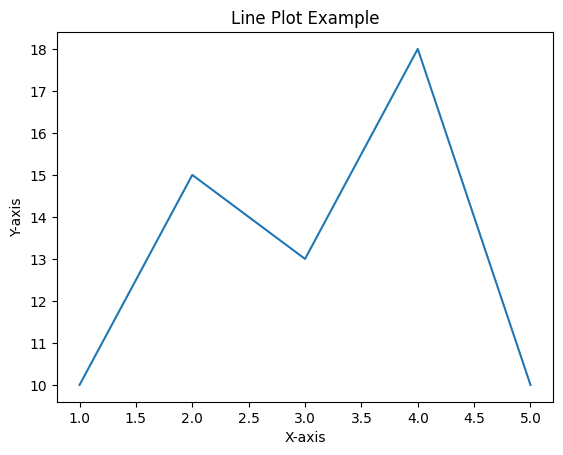

In [18]:
# Line plot example
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [10, 15, 13, 18, 10]

plt.plot(x, y)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Line Plot Example')
plt.show()

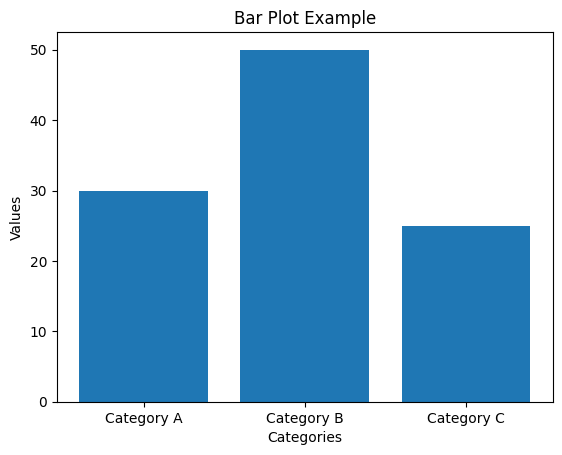

In [19]:
# Bar plot example
import matplotlib.pyplot as plt

categories = ['Category A', 'Category B', 'Category C']
values = [30, 50, 25]

plt.bar(categories, values)
plt.xlabel('Categories')
plt.ylabel('Values')
plt.title('Bar Plot Example')
plt.show()

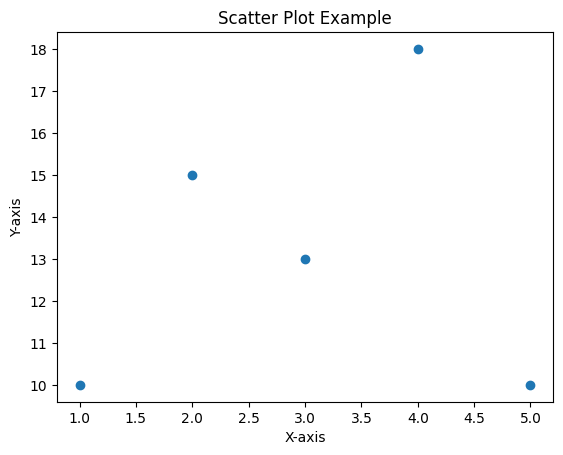

In [20]:
# Scatter plot example
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [10, 15, 13, 18, 10]

plt.scatter(x, y)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Scatter Plot Example')
plt.show()

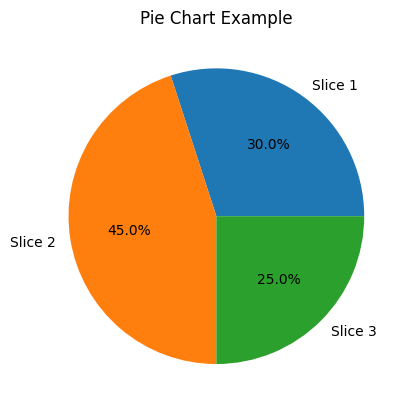

In [21]:
# Pie chart example
import matplotlib.pyplot as plt

sizes = [30, 45, 25]
labels = ['Slice 1', 'Slice 2', 'Slice 3']

plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Pie Chart Example')
plt.show()

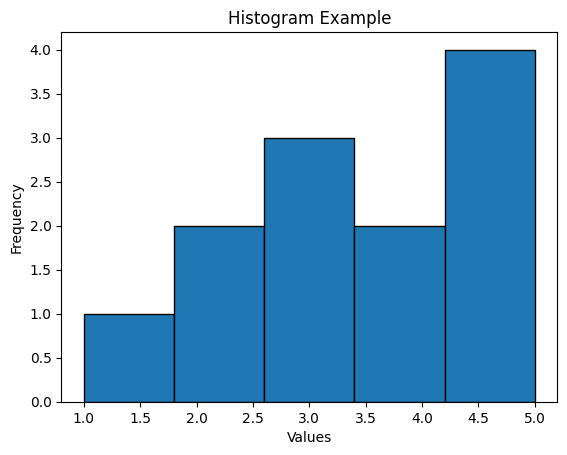

In [22]:
# Histogram example
import matplotlib.pyplot as plt

data = [1, 2, 2, 3, 3, 3, 4, 4, 5, 5, 5, 5]

plt.hist(data, bins=5, edgecolor='black')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram Example')
plt.show()

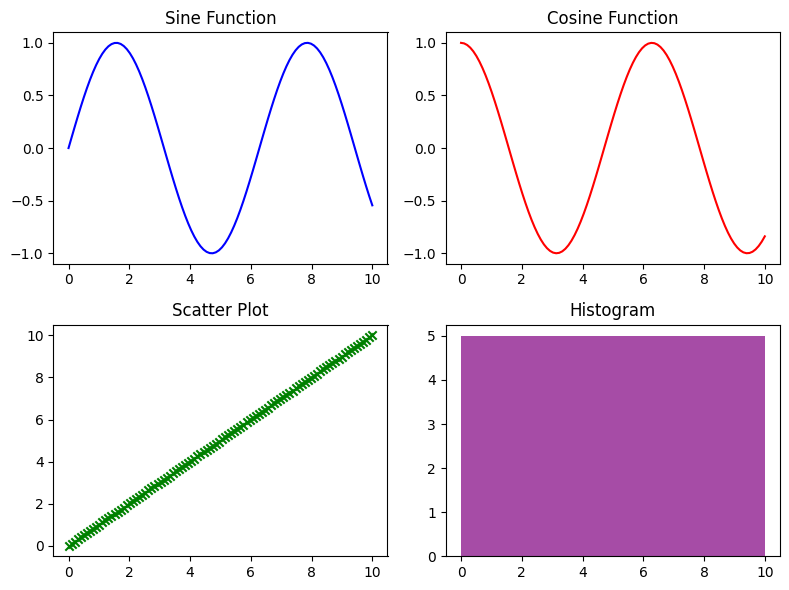

In [23]:
# Creating subplots example
import matplotlib.pyplot as plt
import numpy as np

# Create sample data
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = x

# Create a figure with multiple subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 6))

# Subplot 1
axes[0, 0].plot(x, y1, color='blue')
axes[0, 0].set_title('Sine Function')

# Subplot 2
axes[0, 1].plot(x, y2, color='red')
axes[0, 1].set_title('Cosine Function')

# Subplot 3
axes[1, 0].scatter(x, y3, color='green', marker='x')
axes[1, 0].set_title('Scatter Plot')

# Subplot 4
axes[1, 1].hist(y3, bins=20, color='purple', alpha=0.7)
axes[1, 1].set_title('Histogram')

# Add spacing between subplots
plt.tight_layout()

# Display the figure
plt.show()


### 8. Seaborn
---
Seaborn is a Python data visualization library based on Matplotlib that provides a high-level interface for creating informative and attractive statistical graphics.

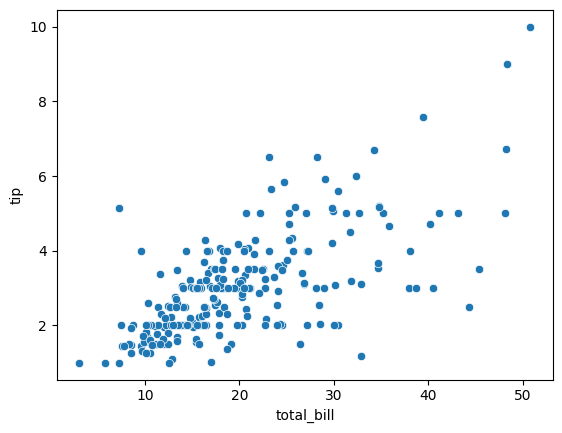

In [24]:
# Scatter plot example
import seaborn as sns
import matplotlib.pyplot as plt

# Load a sample dataset
tips = sns.load_dataset("tips")

# Create a scatter plot
sns.scatterplot(x="total_bill", y="tip", data=tips)
plt.show()

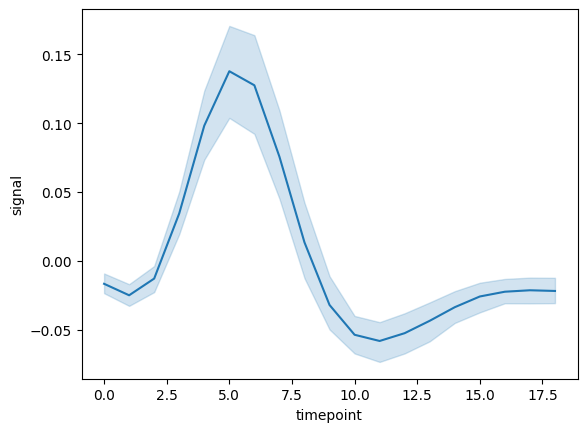

In [25]:
# Line plot example
import seaborn as sns
import matplotlib.pyplot as plt

# Load a sample dataset
fmri = sns.load_dataset("fmri")

# Create a line plot
sns.lineplot(x="timepoint", y="signal", data=fmri)
plt.show()

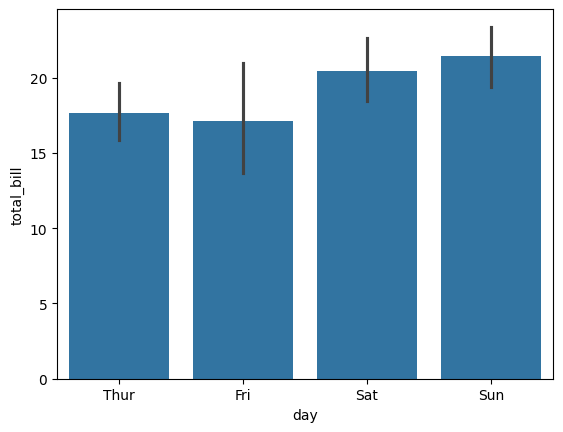

In [26]:
# Bar plot example
import seaborn as sns
import matplotlib.pyplot as plt

# Load a sample dataset
tips = sns.load_dataset("tips")

# Create a bar plot
sns.barplot(x="day", y="total_bill", data=tips)
plt.show()

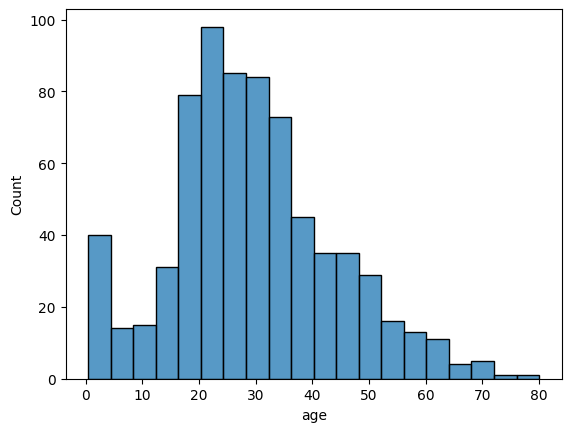

In [27]:
# Histogram example
import seaborn as sns
import matplotlib.pyplot as plt

# Load a sample dataset
titanic = sns.load_dataset("titanic")

# Create a histogram
sns.histplot(titanic["age"], bins=20)
plt.show()

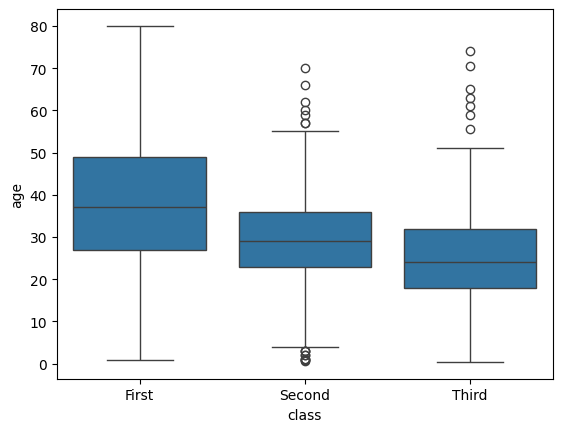

In [28]:
# Box plot example
import seaborn as sns
import matplotlib.pyplot as plt

# Load a sample dataset
titanic = sns.load_dataset("titanic")

# Create a box plot
sns.boxplot(x="class", y="age", data=titanic)
plt.show()

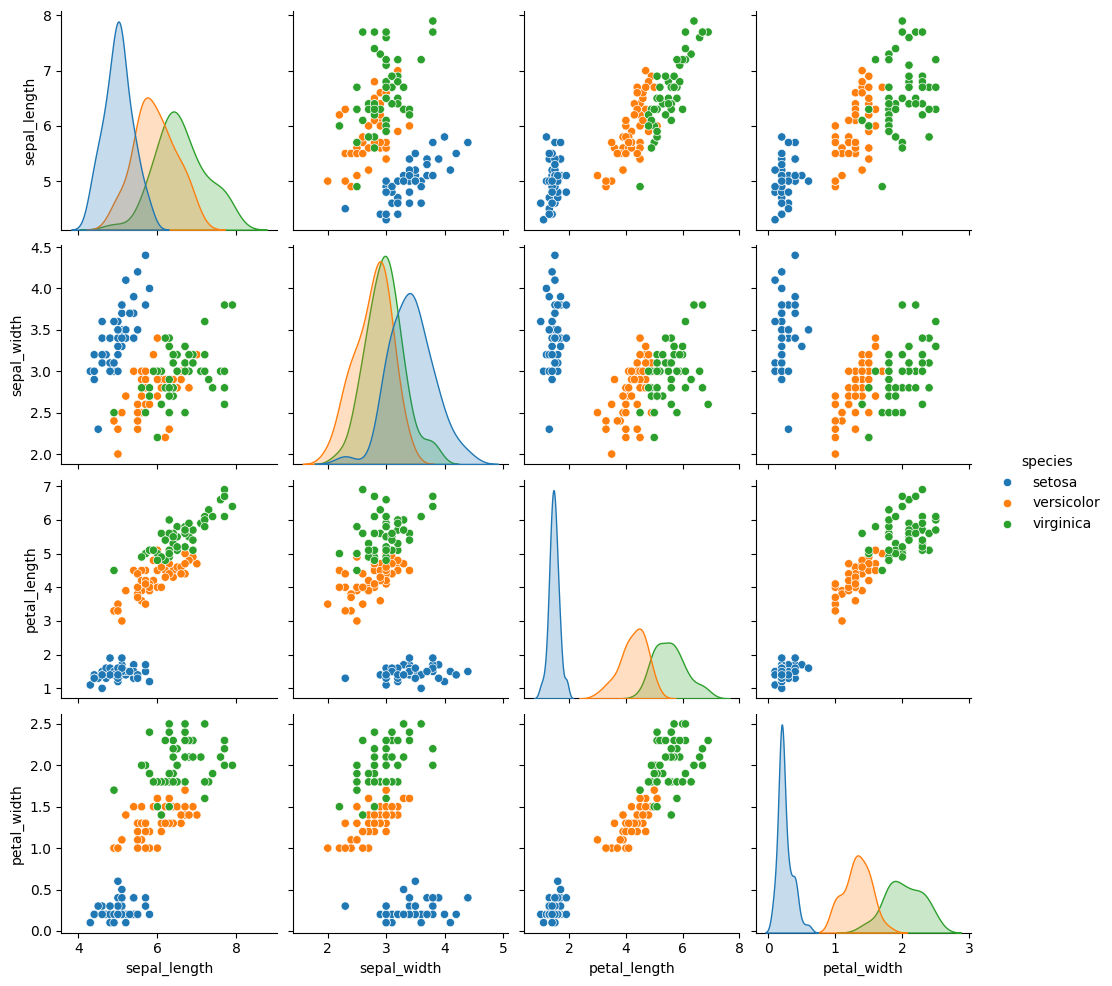

In [29]:
# Pair plot example
import seaborn as sns
import matplotlib.pyplot as plt

# Load a sample dataset
iris = sns.load_dataset("iris")

# Create a pair plot to explore relationships
sns.pairplot(iris, hue="species")
plt.show()

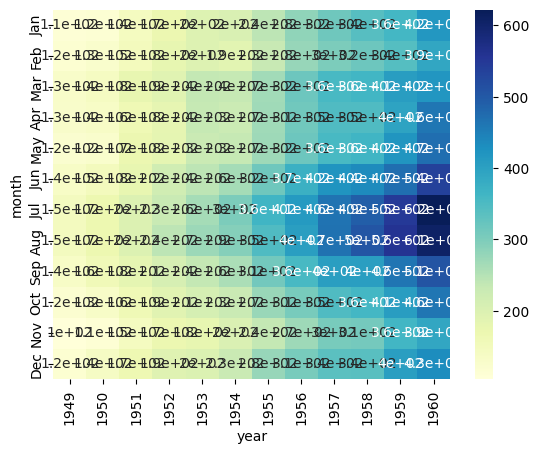

In [30]:
# Heatmap example
import seaborn as sns
import matplotlib.pyplot as plt

# Load a sample dataset
flights = sns.load_dataset("flights")

# Reshape data for a heatmap
flights_pivot = flights.pivot_table(index="month", columns="year", values="passengers")

# Create a heatmap
sns.heatmap(flights_pivot, cmap="YlGnBu", annot=True)
plt.show()

**Exercise 1: Custom Deep Copy Implementation**

Write your own version of deepcopy() (without using copy.deepcopy).

Requirements:

*   Handle lists and nested lists
*   Do NOT use built-in copy utilities
*   Extend it to support dictionaries.


In [31]:
""" this is wrong
def deep_copy(obj):
    if isinstance(obj, list):
        return [deep_copy(item) for item in obj]
    elif isinstance(obj, dict):
        return {deep_copy(k): deep_copy(v) for k, v in obj.items()}
    elif isinstance(obj, tuple):
        return tuple(deep_copy(item) for item in obj)
    else:
        return obj
    """

' this is wrong\ndef deep_copy(obj):\n    if isinstance(obj, list):\n        return [deep_copy(item) for item in obj]\n    elif isinstance(obj, dict):\n        return {deep_copy(k): deep_copy(v) for k, v in obj.items()}\n    elif isinstance(obj, tuple):\n        return tuple(deep_copy(item) for item in obj)\n    else:\n        return obj\n    '

**Excercise 2: Decorators**

Create a function counter decorator that counts how many times a function is called and prints the count.

In [32]:
counter = 0;
def my_decorator(func):
    def wrapper():
      global counter
      counter += 1
      func()
      print(f"Function has been called {counter} times.\n")
    return wrapper

@my_decorator
def say_hello():
    print("Hello!")

say_hello()
say_hello()
say_hello()

Hello!
Function has been called 1 times.

Hello!
Function has been called 2 times.

Hello!
Function has been called 3 times.



**Exercise 3: Energy Consumption Calculation from Power Profile**

A device operates for 90 minutes, during which its power consumption varies over time. The power profile is provided in the **table from the lecture slides**. Assume that the power remains **constant between measurement points**.

- Determine the **total energy consumption** of the device over the entire 90-minute period.

In [33]:
power_list = [0,5,5,10,10,10,5] #kWh
time_list = [0,15,30,45,60,75,90] # dt  = 15min = 0.25h
"""
with open('/content/current.txt', 'r') as file:
    lines = file.readlines()
    for line in lines:
      current_list.append(float(line))

with open('/content/voltage.txt','r') as file:
  lines = file.readlines()
  for line in lines:
    power_list.append(float(line))
"""
delta_time = 0.25 # 15min
Energy = 0
for i in range(len(power_list)):
  delta_time = (time_list[i] - time_list[i-1])/60
  Energy += power_list[i] * delta_time

print(f"Total Energy used: {Energy} kWh\n")

Total Energy used: 11.25 kWh



**Excercise 4: Active, reactive and apparent power**

Given the voltage $u(t)$ and current $i(t)$ waveforms (visualise them) of an electrical circuit, determine the following quantities:

- Active power $P$  
- Reactive power $Q$  
- Apparent power $S$  

What is the type of reactive power?

---

### Computing procedure

1. Calculate the instantaneous power:
$$
p(t) = u(t)\, i(t)
$$

2. Determine the active power:
$$
P = \frac{1}{T} \int_{0}^{T} u(t)\, i(t)\, dt
$$

3. Calculate the RMS values of voltage and current:
$$
U_{\mathrm{rms}} = \sqrt{\frac{1}{T} \int_{0}^{T} u^2(t)\, dt}
$$

$$
I_{\mathrm{rms}} = \sqrt{\frac{1}{T} \int_{0}^{T} i^2(t)\, dt}
$$

4. Determine the apparent power:
$$
S = U_{\mathrm{rms}} \cdot I_{\mathrm{rms}}
$$

5. Compute the reactive power:
$$
Q = \sqrt{S^2 - P^2}
$$

---

### Notes

- Assume the signals are periodic with period $T$.
- For sinusoidal waveforms, using RMS values:
$$
P = U_{\mathrm{rms}} \, I_{\mathrm{rms}} \, \cos\varphi
$$

$$
Q = U_{\mathrm{rms}} \, I_{\mathrm{rms}} \, \sin\varphi
$$

$$
S = U_{\mathrm{rms}} \, I_{\mathrm{rms}}
$$

In [34]:
import numpy as np
import matplotlib.pyplot as plt

voltage_list = []
current_list = []
Period = 1/50 # 20ms
with open('/content/current.txt', 'r') as file:
    lines = file.readlines()
    for line in lines:
      current_list.append(float(line))

with open('/content/voltage.txt','r') as file:
  lines = file.readlines()
  for line in lines:
    voltage_list.append(float(line))

print(voltage_list)
print(current_list)
time = np.linspace(0,1,len(voltage_list))
plt.plot(time,voltage_list)
plt.plot(time,current_list)
#sns.scatterplot(y=voltage_list,x=time)
plt.show()
inst_power_list = []
for i in range(len(voltage_list)):
  inst_power_list.append( voltage_list[i] * current_list[i])
print(inst_power_list)

FileNotFoundError: [Errno 2] No such file or directory: '/content/current.txt'